#### Trying to test GAUSSIAN PROCESSS REGRESSION

In [1]:
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train_df = pd.read_csv("DailyDelhiClimateTrain.csv")
test_df = pd.read_csv("DailyDelhiClimateTest.csv")

In [3]:
train_df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


### I'm going to try and predict the temperature. My metric will be the RMSE

In [4]:
### Preprocessing

In [5]:
train_df.isna().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [6]:
test_df.isna().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

### The dataset contains no missing values

In [7]:
train_df.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


Several variables contain outliers, but the most problematic ones appear in `meanpressure`.
The mean is around 1011, while the maximum reaches 7679, whereas the 75% quantile is only 1014.
This indicates the presence of extreme abnormal values.
 
To handle them, I clip the pressure values using empirical quantiles.
After plotting the distribution restricted to the interval between the $\alpha$ and $1-\alpha$ quantiles for several values of $\alpha$,
I observed that taking $\alpha = 0.01$ retains almost all of the meaningful mass of the distribution.

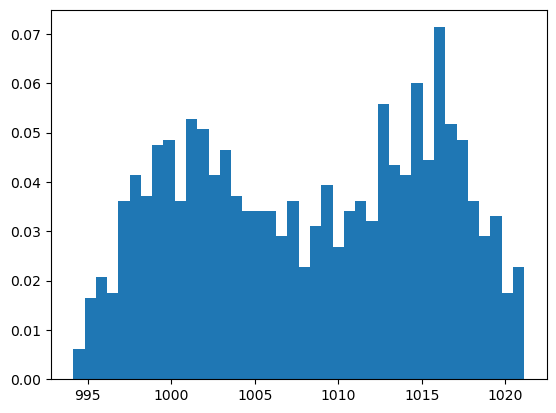

In [8]:
pressure = np.array(train_df["meanpressure"])
sorted_pressure = np.sort(pressure)
n = len(pressure)
plt.hist(sorted_pressure[int(0.01*n):int(0.99*n)], bins=40, density=True)
plt.show()


np.mean(pressure)

pressure_inf = sorted_pressure[int(0.01*n)]
pressure_sup = sorted_pressure[int(0.99*n)]

train_df["meanpressure_clipped"] = train_df["meanpressure"].clip(lower=pressure_inf, upper=pressure_sup)
test_df["meanpressure_clipped"] = test_df["meanpressure"].clip(lower=pressure_inf, upper=pressure_sup)


 ### Plotting the temperature series to get an initial sense of its temporal structure

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(train_df["date"], train_df["meantemp"])
plt.show()


 As expected, the temperature exhibits a clear cyclical pattern.
 Capturing this periodic structure will be essential for accurate prediction.


 Next, I examine the distributions of the input variables.

/tmp/ipykernel_705886/3336102658.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1,0].legend()


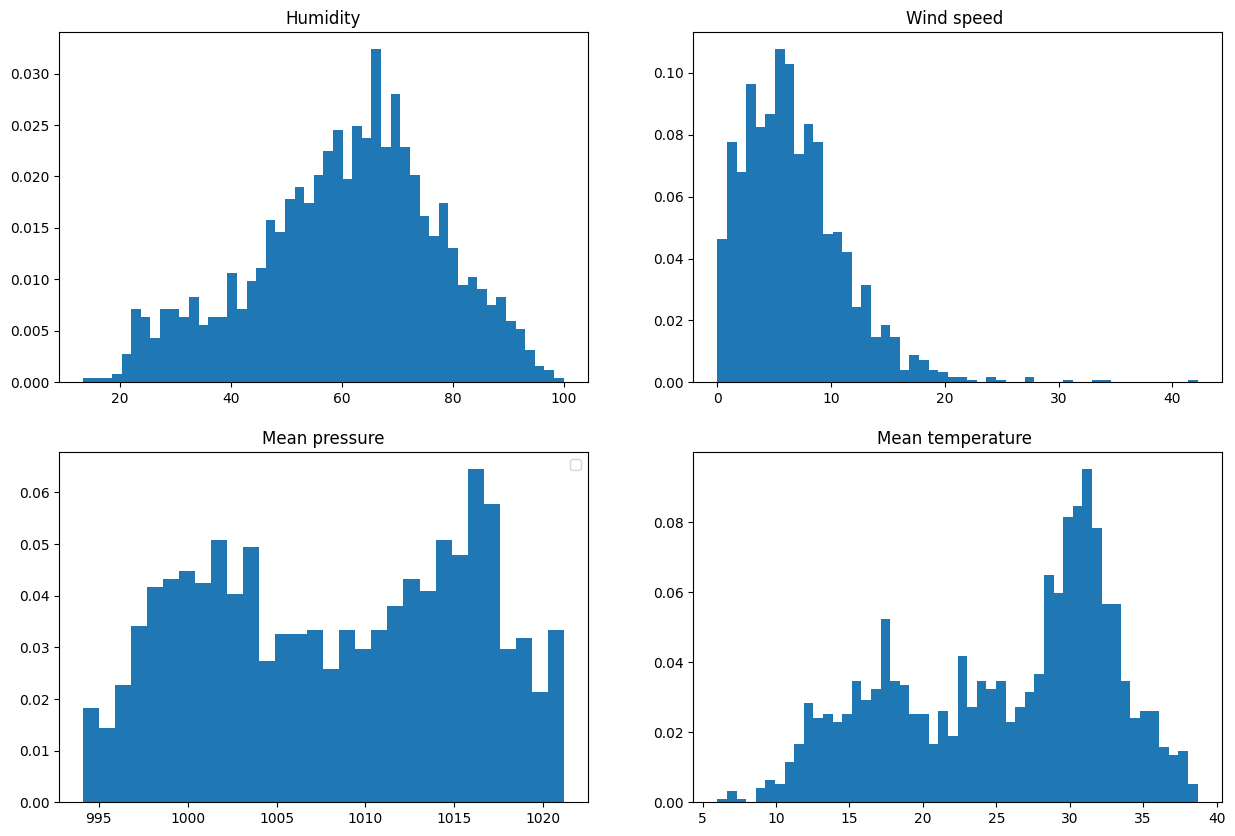

In [ ]:
### Exploring other features
fig, ax = plt.subplots(figsize=(15,10), nrows=2, ncols=2)
ax[0,0].hist(train_df["humidity"], bins=50, density=True)
ax[0,0].set_title("Humidity")


ax[0,1].hist(train_df["wind_speed"], bins=50,density=True)
ax[0,1].set_title("Wind speed ")

ax[1,0].hist(train_df["meanpressure_clipped"], bins=30,density=True)
ax[1,0].set_title("Mean pressure")
ax[1,0].legend()

ax[1,1].hist(train_df["meantemp"], bins=50,density=True)
ax[1,1].set_title("Mean temperature ")
plt.show()

In [ ]:
### To get things going, I convert the date into a number
train_df["date"] = pd.to_datetime(train_df["date"])
origine = train_df["date"].min()
train_df["date_num"] = train_df["date"] - origine
train_df["date_num"] = train_df["date_num"].dt.days

train_df = train_df.drop(columns=["date"])

### To get things going, I convert the date into a number
test_df["date"] = pd.to_datetime(test_df["date"])
test_df["date_num"] = test_df["date"] - origine
test_df["date_num"] = test_df["date_num"].dt.days

test_df = test_df.drop(columns=["date"])

In [ ]:
train_df.head()

,meantemp,humidity,wind_speed,meanpressure,meanpressure_clipped,date_num
0,10.000000,84.500000,0.000000,1015.666667,1015.666667,0
1,7.400000,92.000000,2.980000,1017.800000,1017.800000,1
2,7.166667,87.000000,4.633333,1018.666667,1018.666667,2
3,8.666667,71.333333,1.233333,1017.166667,1017.166667,3
4,6.000000,86.833333,3.700000,1016.500000,1016.500000,4



 Scaling the variables before training

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
columns = ["humidity", "meanpressure_clipped", "wind_speed", "date_num"]
X_train, y_train = np.array(train_df[columns]), np.array(train_df["meantemp"])
X_train_s = scaler.fit_transform(X_train)
X_train_s[:,-1] = X_train[:,-1]

X_test, y_test = np.array(test_df[columns]), np.array(test_df["meantemp"])
X_test_s = scaler.transform(X_test)
X_test_s[:,-1] = X_test[:,-1]


In [ ]:
def add_sin(X,period=352):
    t = X[:,-1].reshape(-1,1)
    X_other = X[:, :-1]

    X_aug = np.hstack([
        np.sin(2*np.pi*t/period),
        np.cos(2*np.pi*t/period),
        X_other
    ])
    
    return X_aug

# X_test_s = add_sin(X_test_s)
# X_train_s = add_sin(X_train_s)


 Before training the models, I examine the correlations between variables to get a rough sense of how much information may be extracted from them.

<Axes: >

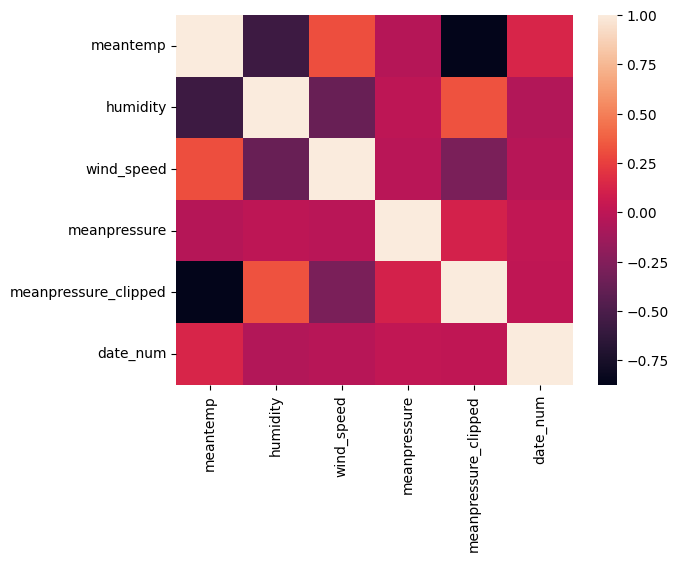

In [ ]:
import seaborn as sns

correlation = train_df.corr()
sns.heatmap(correlation)


 This highlights the benefit of preprocessing `meanpressure`.
 The raw pressure variable has almost no correlation with `meantemp`,
 whereas the clipped version shows a noticeably stronger correlation in absolute value.
 Another important observation is that several features are correlated with one another.

<Axes: >

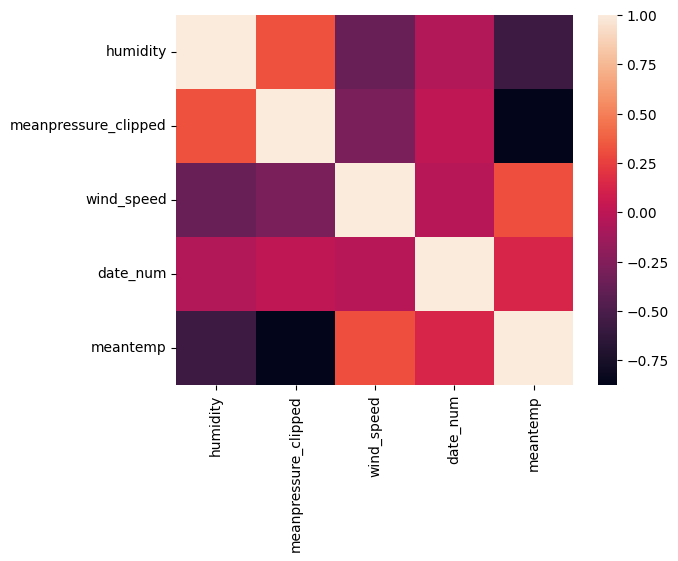

In [ ]:
sns.heatmap(train_df[columns+["meantemp"]].corr())


 Note that these are only linear correlations.
 In particular, the weak correlation between temperature and date does not mean that no relationship exists,
 only that this relationship is not well described by a linear trend.

### Model definition and training

In [ ]:
from sklearn.gaussian_process.kernels import ConstantKernel, ExpSineSquared, RBF, RationalQuadratic, WhiteKernel



 I first use the time variable to capture the main trend and seasonal structure,
 then model the residual component using the remaining features.
 The goal is to improve the overall RMSE while keeping the decomposition interpretable.


 Formally, I consider the decomposition
 
 $$\begin{aligned}
 T(t,w,p,h) &= T(\text{time}, \text{wind}, \text{pressure}, \text{humidity}) \\
 &= f(t) + g(w,p,h).
 \end{aligned}$$
 
 The time component is expected to capture seasonal effects and long-term temporal structure,
 while the second term accounts for the additional variability explained by the meteorological covariates.

In [ ]:


seasonal_kernel = 5**2 * ExpSineSquared(length_scale=20, 
                                        periodicity=365, 
                                        periodicity_bounds ="fixed")

irregularities_kernel = 2**2 * RationalQuadratic(
    length_scale=20.0,
    length_scale_bounds=(20.0, 200.0),
    alpha=7.0,
    alpha_bounds=(2.0, 20.0)
)

noise_kernel1 = WhiteKernel(
    noise_level=1,
    noise_level_bounds=(1e-1, 10.0)
)

tendencies = 1* RBF(
    length_scale=1
)

noise_kernel2 = WhiteKernel(
    noise_level=1,
    noise_level_bounds=(1e-5, 10.0)
)
time_kernel = tendencies + seasonal_kernel  + noise_kernel1
other_features_kernel = tendencies + irregularities_kernel + noise_kernel2

In [ ]:
y_mean = np.mean(y_train)

time_gp = GaussianProcessRegressor(
    kernel=time_kernel,
    normalize_y=True,
    n_restarts_optimizer=5,
    alpha=1e-6,
    random_state=0
)
time_gp.fit(X_train_s[:,-1].reshape(-1,1), y_train - y_mean)

residuals = y_train - y_mean - time_gp.predict(X_train[:,-1].reshape(-1,1), return_std=False)

other_gp = GaussianProcessRegressor(
    kernel=other_features_kernel,
    normalize_y=True,
    n_restarts_optimizer=5,
    alpha=1e-6,
    random_state=0
)

other_gp.fit(X_train_s[:,:-1], residuals)

/users/eleves-b/2023/bidias.tiotsop-ngueguim/Documents/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/users/eleves-b/2023/bidias.tiotsop-ngueguim/Documents/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k2__length_scale is close to the specified lower bound 20.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(alpha=1e-06,
                         kernel=1**2 * RBF(length_scale=1) + 2**2 * RationalQuadratic(alpha=7, length_scale=20) + WhiteKernel(noise_level=1),
                         n_restarts_optimizer=5, normalize_y=True,
                         random_state=0)

In [ ]:
print(time_gp.kernel_)
print(other_gp.kernel_)

0.227**2 * RBF(length_scale=4.94) + 1.19**2 * ExpSineSquared(length_scale=1.3, periodicity=365) + WhiteKernel(noise_level=0.1)
0.639**2 * RBF(length_scale=1.41) + 3.73**2 * RationalQuadratic(alpha=7.22, length_scale=20) + WhiteKernel(noise_level=0.81)


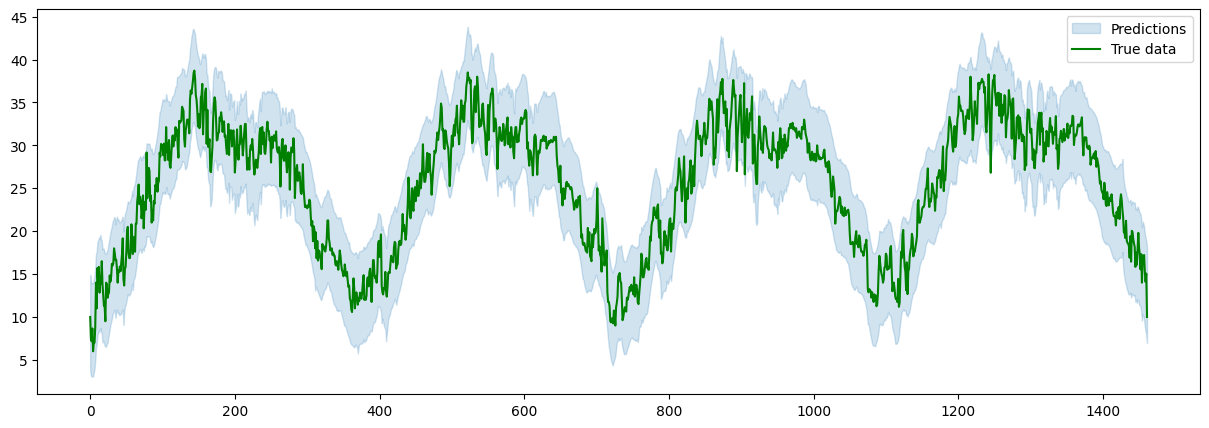

In [ ]:
pred1, std1 = time_gp.predict(X_train_s[:,-1].reshape(-1,1), return_std=True)
pred2, std2 = other_gp.predict(X_train_s[:,:-1], return_std=True)

plt.figure(figsize=(15,5))
plt.fill_between(
    X_train[:,-1],
    pred1 + y_mean + pred2 - 1.96*np.sqrt(std1**2+std2**2),
    pred1 + y_mean + pred2 + 1.96*np.sqrt(std1**2+std2**2),
    color="tab:blue",
    alpha=0.2,
    label="Predictions"
)

plt.plot(X_train[:,-1], y_train,label="True data", color="green")
plt.legend()
plt.show()


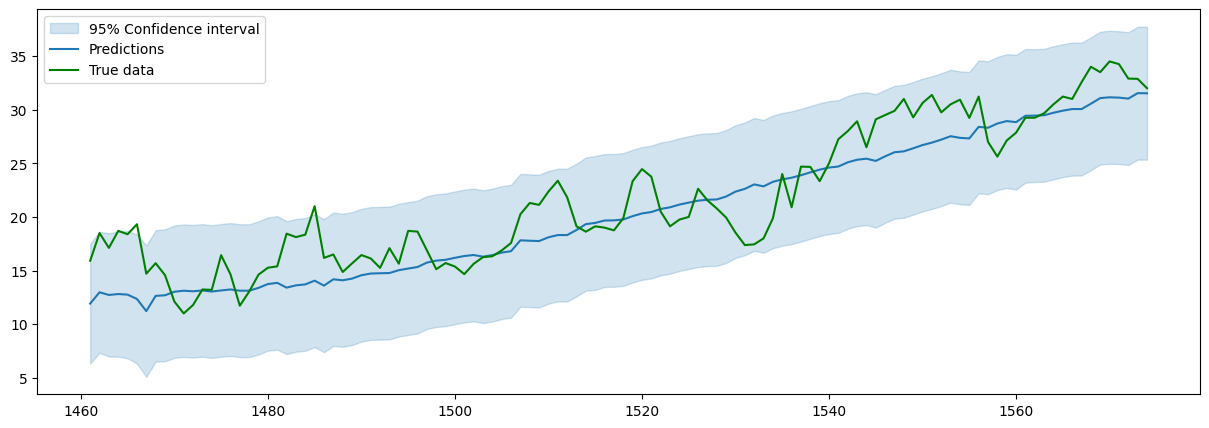

In [ ]:
pred1, std1 = time_gp.predict(X_test_s[:,-1].reshape(-1,1), return_std=True)
pred2, std2 = other_gp.predict(X_test_s[:,:-1], return_std=True)

plt.figure(figsize=(15,5))
plt.fill_between(
    X_test[:,-1],
    pred1 + y_mean + pred2 - 1.96*np.sqrt(std1**2+std2**2),
    pred1 + y_mean + pred2 + 1.96*np.sqrt(std1**2+std2**2),
    color="tab:blue",
    alpha=0.2,
    label="95% Confidence interval"
)
plt.plot(X_test[:,-1], pred1 + y_mean + pred2, label="Predictions")
plt.plot(X_test[:,-1], y_test,label="True data", color="green")
plt.legend()
plt.show()


In [ ]:
rmse = np.mean((pred1 + y_mean + pred2 - y_test )**2)**0.5
erreur_norm = np.mean((pred1 + y_mean + pred2 - y_test )**2 / (std1**2 + std2**2))

In [ ]:
print(f"rmse {rmse: .4f}")
print(f"Normalised prediction error : {erreur_norm: .4f}")

rmse  2.8299
Normalised prediction error :  0.8229



#### Comparing this Gaussian process approach with a Fourier-features baseline combined with XGBoost for residual modeling

In [ ]:
def add_sinusoidals(periods, X,t):
    new_cols = np.zeros((len(X), 2*len(periods)))
    for i,T in enumerate(periods):
        new_cols[:,2*i] = np.cos(2*np.pi*t/T)
        new_cols[:,2*i+1] = np.sin(2*np.pi*t/T)
        
    newX = np.hstack([new_cols, X])
    
    return newX

In [ ]:
T, n_periods = 365*2, 4
X_train_with_fourier = add_sinusoidals(np.arange(T/n_periods, T, T/n_periods), X_train_s, X_train[:,-1])
X_test_with_fourier = add_sinusoidals(np.arange(T/n_periods, T, T/n_periods), X_test_s, X_test[:,-1])

In [ ]:
from sklearn.linear_model import LinearRegression
cols = list(range(2*n_periods))+[-1]
lr = LinearRegression().fit(X_train_with_fourier[:,cols], y_train)

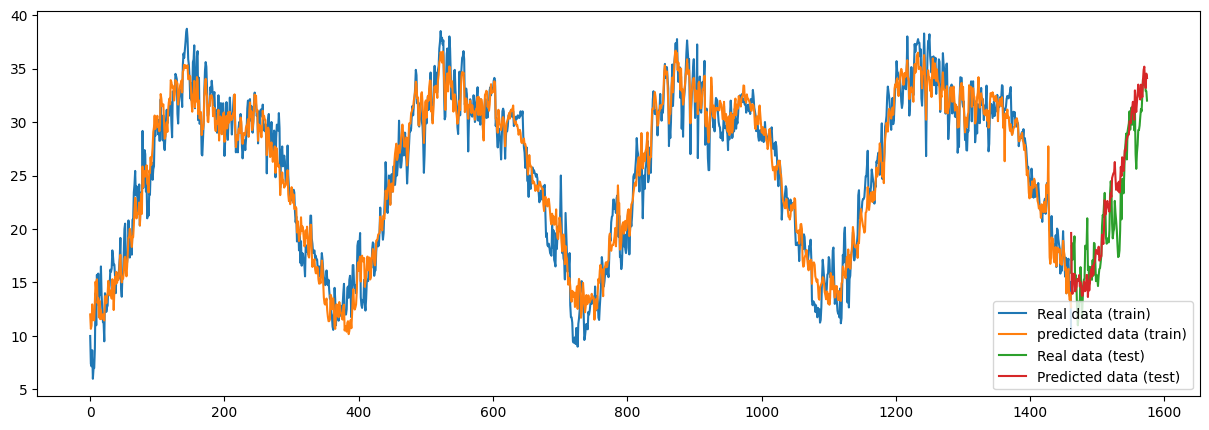

In [ ]:
y_preds = lr.predict(X_test_with_fourier[:,cols])

plt.figure(figsize=(15,5))
plt.plot(X_train[:,-1], y_train, label="Real data (train)")
plt.plot(X_train[:,-1], lr.predict(X_train_with_fourier[:,cols]), label="predicted data (train)")
plt.plot(X_test[:,-1], y_test, label="Real data (test)")
plt.plot(X_test[:,-1], y_preds, label="Predicted data (test)")
plt.legend()

plt.show()

In [ ]:
train_pred = lr.predict(X_train_with_fourier[:,cols])
residuals = y_train - train_pred

In [ ]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from scipy.stats import randint, uniform, loguniform

X_res_train = X_train_s
y_res_train = residuals

residuals_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=0,
    n_jobs=-1
)

param_distributions = {
    "n_estimators": randint(200, 1200),
    "learning_rate": loguniform(1e-3, 5e-1),
    "max_depth": randint(2, 20),
    "min_child_weight": randint(1, 10),
    "subsample": uniform(0.6, 0.4)      # entre 0.6 et 1.0
}

tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    estimator=residuals_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    random_state=0,
    n_jobs=-1,
    refit=True
)

search.fit(X_res_train, y_res_train)

print("Best parameters :")
print(search.best_params_)

print("Best cross validation score :")
print(search.best_score_)

best_residuals_model = search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Best parameters :
{'learning_rate': 0.0018854537484233858, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 380, 'subsample': 0.7013166410159128}
Best cross validation score :
-1.689872877277864


In [ ]:
residuals_pred = best_residuals_model.predict(X_test_s)

rmse = np.sqrt(mean_squared_error(y_test, y_pred+residuals_pred))
print("RMSE :", rmse)

RMSE : 3.514918091739784


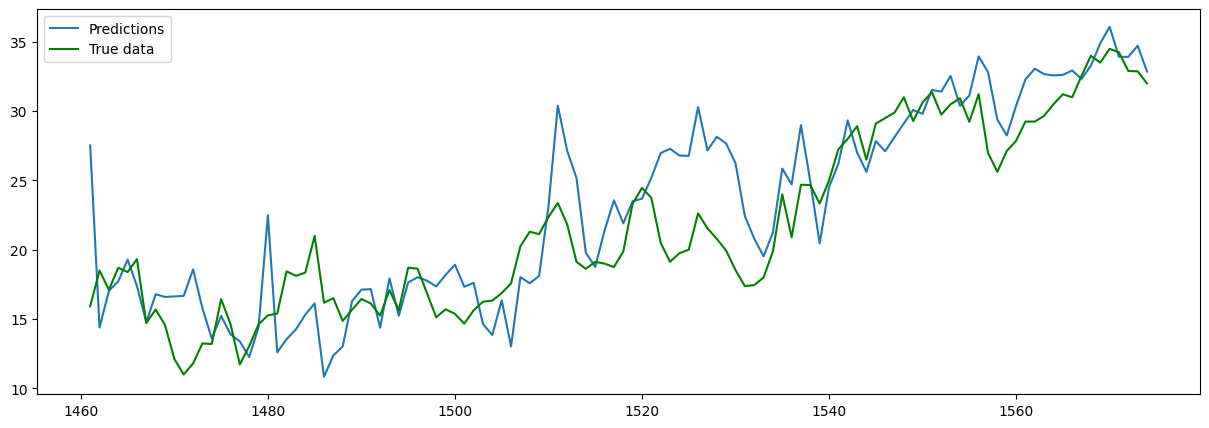

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(X_test[:,-1], y_pred + residuals_pred, label="Predictions")
plt.plot(X_test[:,-1], y_test,label="True data", color="green")
plt.legend()
plt.show()


I obtain results a little bit worse than before, since we get a bigger RMSE.

 #### Next, I'll try to learn from the residuals with a gaussian process.

In [ ]:
#### Entraînement des résidus avec un GP

residuals_kernel = 1*RBF(length_scale=20) + 1*RBF(length_scale=10)

residuals_gp = GaussianProcessRegressor(kernel=residuals_kernel,
                                        n_restarts_optimizer=5,
                                        normalize_y=True)


In [ ]:
residuals_gp.fit(X_train_s[:,:-1], residuals)

GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=20) + 1**2 * RBF(length_scale=10),
                         n_restarts_optimizer=5, normalize_y=True)

In [ ]:
residuals_gp.kernel_

0.493**2 * RBF(length_scale=0.881) + 0.932**2 * RBF(length_scale=0.00121)

In [ ]:
residuals_pred_train, stds_train = residuals_gp.predict(X_train_s[:,:-1], return_std=True)
residuals_pred_test, stds_test = residuals_gp.predict(X_test_s[:,:-1], return_std=True)

fourier_gp_trp = residuals_pred_train + lr.predict(X_train_with_fourier[:,cols])
fourier_gp_tep = residuals_pred_test + lr.predict(X_test_with_fourier[:,cols])

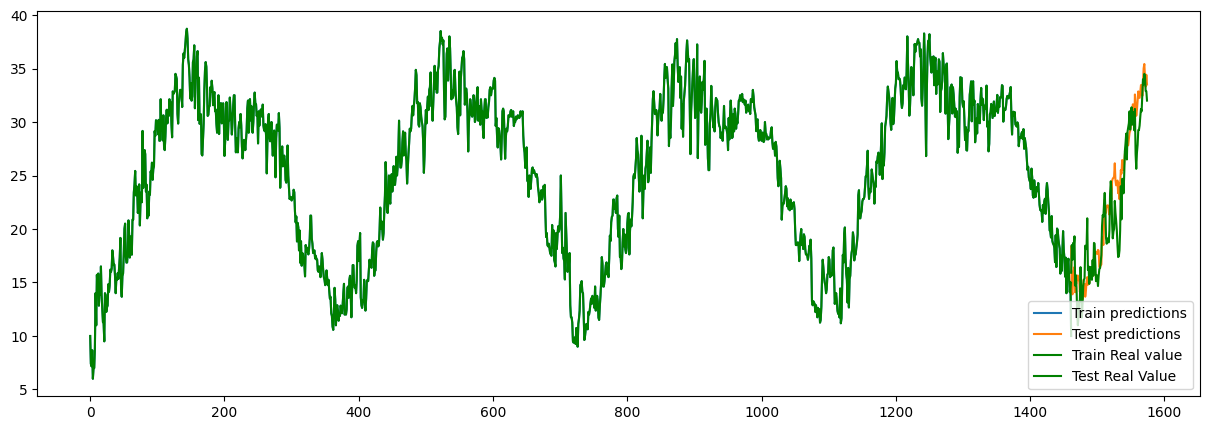

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(X_train[:,-1], fourier_gp_trp,label="Train predictions")
plt.plot(X_test[:,-1], fourier_gp_tep,label="Test predictions")

plt.plot(X_train[:,-1], y_train,label="Train Real value", color="green")
plt.plot(X_test[:,-1], y_test,label="Test Real Value", color="green")
plt.legend()
plt.show()

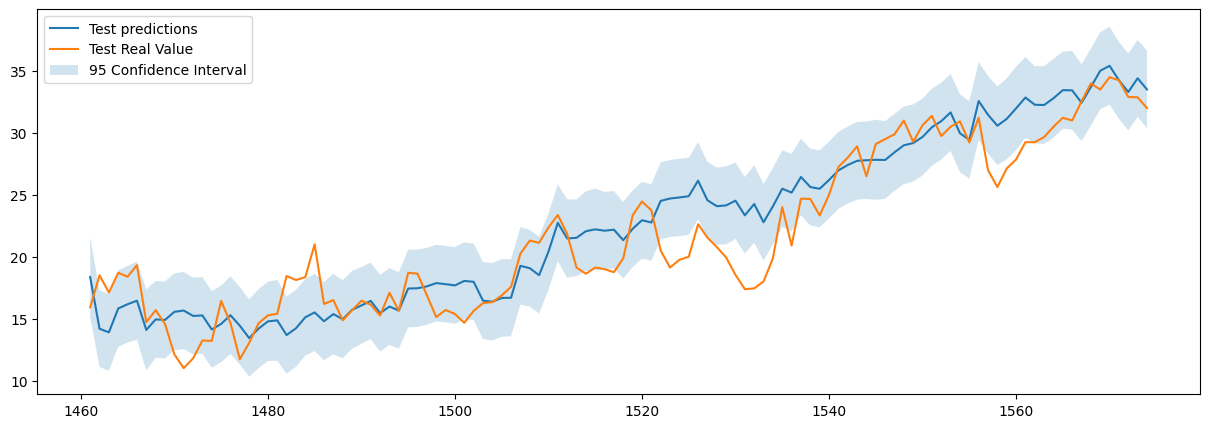

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(X_test[:,-1], fourier_gp_tep,label="Test predictions")
plt.plot(X_test[:,-1], y_test,label="Test Real Value")

plt.fill_between(X_test[:,-1],
                 fourier_gp_tep+1.96*stds_test,
                 fourier_gp_tep-1.96*stds_test,
                 alpha=0.2,
                 label="95 Confidence Interval")

plt.legend()
plt.show()

In [ ]:
rmse = np.mean((fourier_gp_tep- y_test )**2)**0.5
erreur_norm = np.mean((fourier_gp_tep - y_test )**2 / (stds_test**2))

In [ ]:
print(f"rmse : {rmse: .4f}")
print(f"Normalised prediction error : {erreur_norm: .4f}")

rmse :  2.6518
Normalised prediction error :  2.7572


Here we obtain a better RMSE, but the normalised prediction error is too huge, signaling that the model predicts too little variance compared to the precision it gives. Said more clearly, it underestimated the error it does.

### XGBoost Only

In [ ]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=0,
    n_jobs=-1
)

param_distributions = {
    "n_estimators": randint(200, 1200),
    "learning_rate": loguniform(1e-3, 5e-1),
    "max_depth": randint(2, 20),
    "min_child_weight": randint(1, 10),
    "subsample": uniform(0.6, 0.4)      # entre 0.6 et 1.0
}

tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    estimator=residuals_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    random_state=0,
    n_jobs=-1,
    refit=True
)

search.fit(X_train_with_fourier, y_train)

print("Best parameters :")
print(search.best_params_)

print("Best cross validation score :")
print(search.best_score_)

best_xgb_model = search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Best parameters :
{'learning_rate': 0.05471548218170719, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 707, 'subsample': 0.7899470061635768}
Best cross validation score :
-2.0015997725763834


In [ ]:
preds = best_xgb_model.predict(X_test_with_fourier)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE :", rmse)

RMSE : 2.6664069753895414


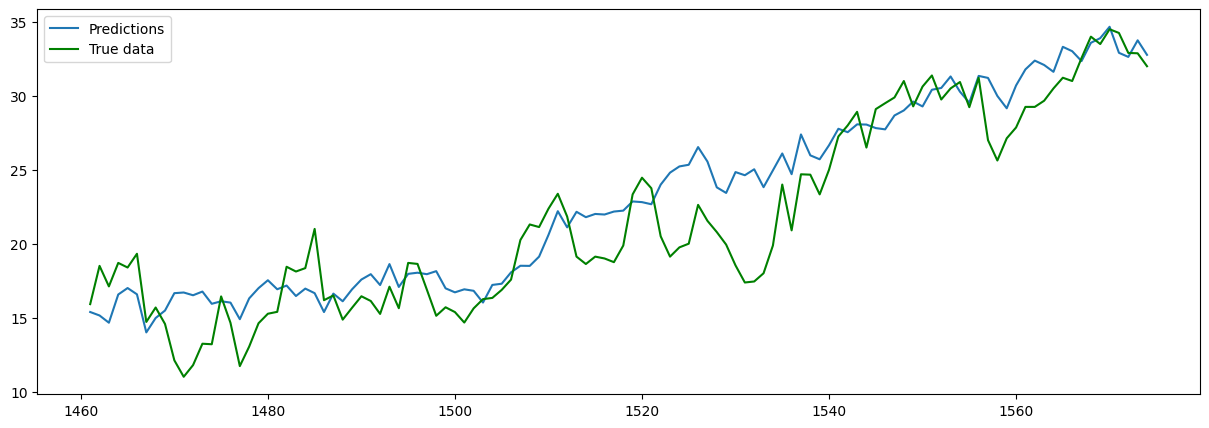

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(X_test[:,-1], preds , label="Predictions")
plt.plot(X_test[:,-1], y_test,label="True data", color="green")
plt.legend()
plt.show()


We obtain slightly lower performances compared to the approach of using linear regression (on fourier features) + gaussian process

### Conclusion

In this notebook, I explored several approaches for forecasting a target variable in a time series setting. I initially expected Gaussian process models to outperform XGBoost-based approaches, but the results suggest otherwise. On this dataset, once the data is properly cleaned and periodic time features are introduced, XGBoost achieves better predictive performance than the Gaussian process models considered here.

Gaussian processes remain attractive because they provide more than point predictions: they also offer confidence intervals and normalized prediction errors, which give a clearer view of the reliability of the model and of the uncertainty attached to each prediction. However, this comes at a substantial computational cost, since training Gaussian process models can be quite slow.

By contrast, XGBoost is much more scalable and, when combined with careful feature engineering, delivers strong predictive performance at a much lower training cost. In this study, this practical advantage translated into better overall results.

A possible direction for future work would be to combine both approaches: for instance, one could train a Gaussian process on a smaller subset of the data and then use its predictions or uncertainty estimates as additional features in a more flexible model such as XGBoost. This idea was not explored in this notebook, but it could be an interesting extension on another dataset.

### References : 

For kernel engineering : <a href="https://gaussianprocess.org/gpml/chapters/RW.pdf">Gaussian Processes for Machine Learning, Chap 5 - 5.4.3</a>

Practical use case of gaussian processes with sklearn : <a href ="https://scikit-learn.org/stable/auto_examples/gaussian_process/plot_gpr_co2.html">Forecasting of CO2 level on Mona Loa dataset using Gaussian process regression (GPR)</a>